# NetworkX: Solutions Manual 
*This notebook contains the solutions to the exercises presented at the end of Notebook 1.*

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

### Solution 1: Academic Collaboration Network
This exercise tested your ability to create a standard, undirected graph and map specific numerical attributes to the edges.

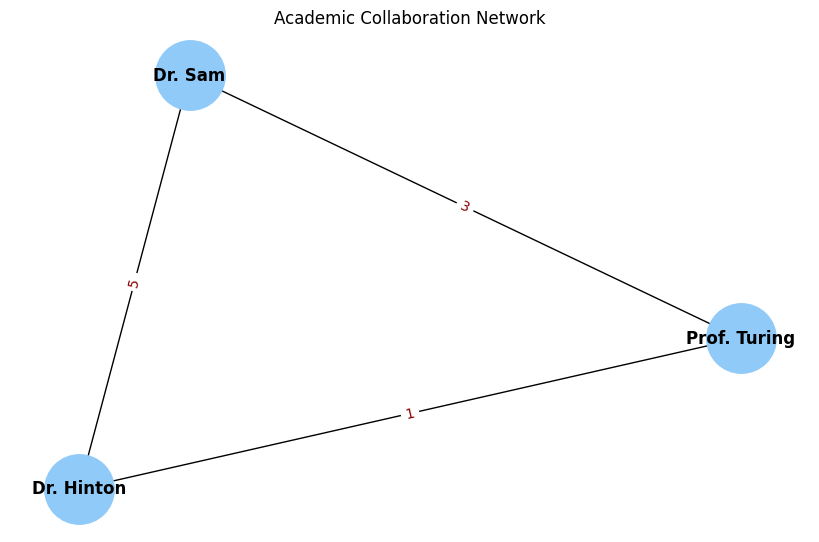

In [2]:
# 1. Initialize Graph
collab_graph = nx.Graph()

# 2. Add Nodes
collab_graph.add_nodes_from(["Dr. Sam", "Prof. Turing", "Dr. Hinton"])

# 3. Add Edges with 'papers' metadata
collab_graph.add_edges_from([
    ("Dr. Sam", "Prof. Turing", {"papers": 3}),
    ("Dr. Sam", "Dr. Hinton", {"papers": 5}),
    ("Prof. Turing", "Dr. Hinton", {"papers": 1})
])

# 4. Plot the graph and edge labels
plt.figure(figsize=(8, 5))
pos = nx.spring_layout(collab_graph, seed=42)

nx.draw(collab_graph, pos, with_labels=True, node_color="#90caf9", node_size=2500, font_weight="bold")

edge_papers = nx.get_edge_attributes(collab_graph, 'papers')
nx.draw_networkx_edge_labels(collab_graph, pos, edge_labels=edge_papers, font_color="darkred")

plt.title("Academic Collaboration Network")
plt.show()

### Solution 2: Triangular Arbitrage Flow
This exercise tested your understanding of `MultiDiGraph` and directional flow. Because a triangular arbitrage ring (A->B, B->C, C->A) uses distinct pairs of nodes for each edge, the arrows don't directly overlap in the same direction, making the built-in `nx.draw` with `connectionstyle` perfectly sufficient.

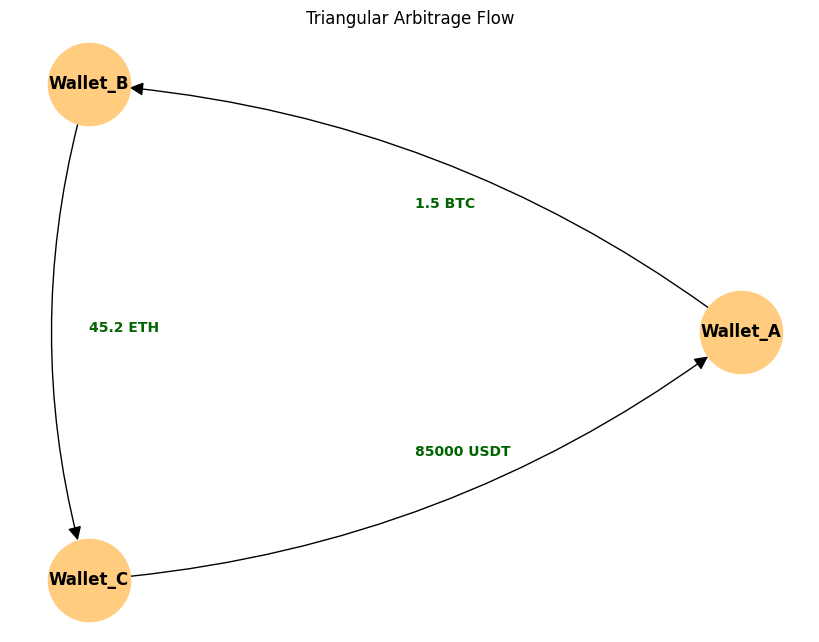

In [3]:
# 1 & 2. Initialize MultiDiGraph
tri_mdg = nx.MultiDiGraph()

# 3 & 4. Add triangular transaction ring
tri_mdg.add_edge("Wallet_A", "Wallet_B", amount=1.5, asset="BTC")
tri_mdg.add_edge("Wallet_B", "Wallet_C", amount=45.2, asset="ETH")
tri_mdg.add_edge("Wallet_C", "Wallet_A", amount=85000, asset="USDT")

# 5. Plot the graph
plt.figure(figsize=(8, 6))
pos_tri = nx.circular_layout(tri_mdg) # Circular layout looks great for triangular flow!

nx.draw(
    tri_mdg, pos_tri, 
    with_labels=True, 
    node_color="#ffcc80", 
    node_size=3500, 
    font_weight="bold",
    arrowsize=20,
    connectionstyle="arc3,rad=0.15" # Slight curve to the arrows
)

# Add labels manually for a clean look
for u, v, data in tri_mdg.edges(data=True):
    x_start, y_start = pos_tri[u]
    x_end, y_end = pos_tri[v]
    plt.text(
        (x_start + x_end) / 2, (y_start + y_end) / 2, 
        f"{data['amount']} {data['asset']}", 
        color="darkgreen", 
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
    )

plt.title("Triangular Arbitrage Flow")
plt.show()

### Solution 3: Expanding the AI Knowledge Graph
This exercise tested your ability to dynamically map attributes (colors) to nodes after expanding an existing architecture. Notice how the list comprehension dynamically adapts to the newly added nodes.

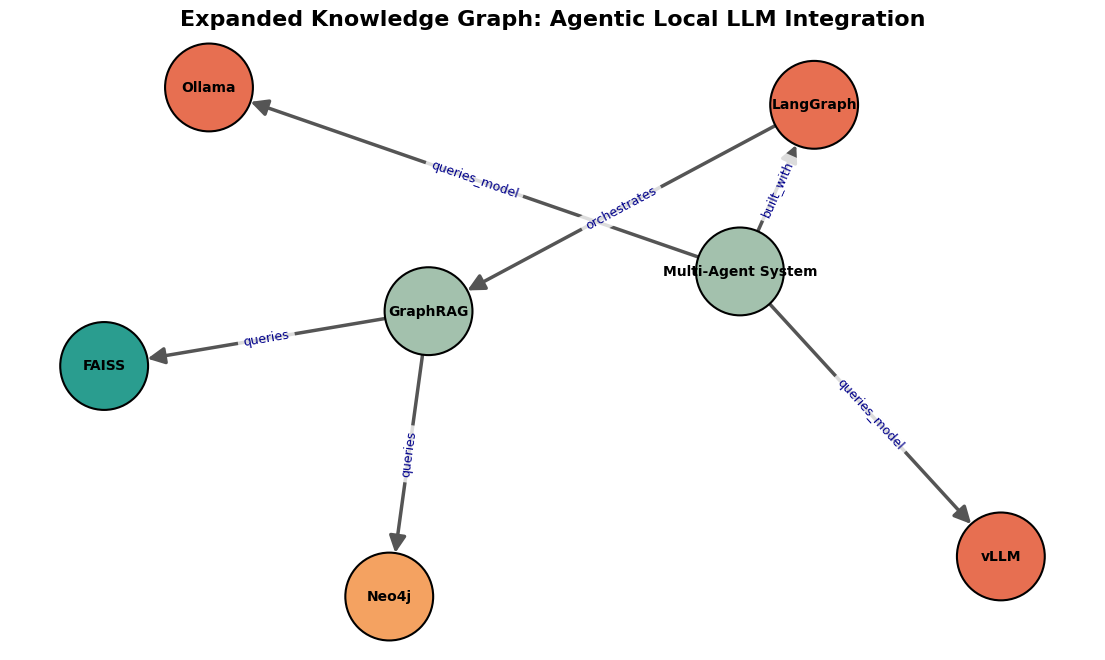

In [4]:
# Recreating the base Knowledge Graph from the tutorial
kg = nx.DiGraph()
kg.add_node("GraphRAG", category="Concept")
kg.add_node("Multi-Agent System", category="Concept")
kg.add_node("Neo4j", category="Graph Database")
kg.add_node("FAISS", category="Vector Database")
kg.add_node("LangGraph", category="Framework")

kg.add_edge("GraphRAG", "Neo4j", relation="queries")
kg.add_edge("GraphRAG", "FAISS", relation="queries")
kg.add_edge("Multi-Agent System", "LangGraph", relation="built_with")
kg.add_edge("LangGraph", "GraphRAG", relation="orchestrates")

# --- SOLUTION START ---

# 2. Add new LLM nodes
kg.add_node("Ollama", category="Framework")
kg.add_node("vLLM", category="Framework")

# 3. Connect them to the Multi-Agent System
kg.add_edge("Multi-Agent System", "Ollama", relation="queries_model")
kg.add_edge("Multi-Agent System", "vLLM", relation="queries_model")

# 4. Re-calculate the color mapping
color_map = {
    "Concept": "#a3c1ad",
    "Graph Database": "#f4a261",
    "Vector Database": "#2a9d8f",
    "Framework": "#e76f51"
}
node_colors = [color_map[kg.nodes[n]['category']] for n in kg.nodes()]

# 5. Re-plot the graph
plt.figure(figsize=(14, 8))
pos = nx.spring_layout(kg, seed=42, k=1.4) 

nx.draw_networkx_nodes(kg, pos, node_color=node_colors, node_size=4000, edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(kg, pos, font_size=10, font_weight="bold", font_color="black")
nx.draw_networkx_edges(kg, pos, edge_color="#555555", width=2.5, arrowsize=25, node_size=4000)

edge_labels = nx.get_edge_attributes(kg, 'relation')
nx.draw_networkx_edge_labels(
    kg, pos, 
    edge_labels=edge_labels, 
    font_size=9, 
    font_color="darkblue", 
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
)

plt.title("Expanded Knowledge Graph: Agentic Local LLM Integration", fontsize=16, fontweight="bold")
plt.axis("off")
plt.show()